<a href="https://colab.research.google.com/github/makarchik-popsik/ai-crypto-hedge-fund/blob/main/CMF_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Baseline Strategy: Simple Moving Average (SMA) Crossover
**Objective:** Establish a benchmark technical strategy to trade Bitcoin (BTC-USD).
**Methodology:** The algorithm utilizes a classic dual-moving-average crossover logic (Short-term SMA vs. Long-term SMA). It generates a buy signal when the fast SMA crosses above the slow SMA, and a sell/flat signal on the reverse crossover.
**Limitations:** Being a pure trend-following indicator, this baseline suffers from significant lag and is highly susceptible to whipsaws (false signals) during sideways or choppy market phases, which degrades the capital growth curve.

/tmp/ipykernel_15893/409933738.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Загрузка данных...
----------------------------------------
Метрики стратегии (BTC-USD):
Buy & Hold ROI:   154.23%
Strategy ROI:     18.50%
Sharpe Ratio:     0.60
Sortino Ratio:    0.69
Max Drawdown:     -26.49%
Calmar Ratio:     0.47
----------------------------------------


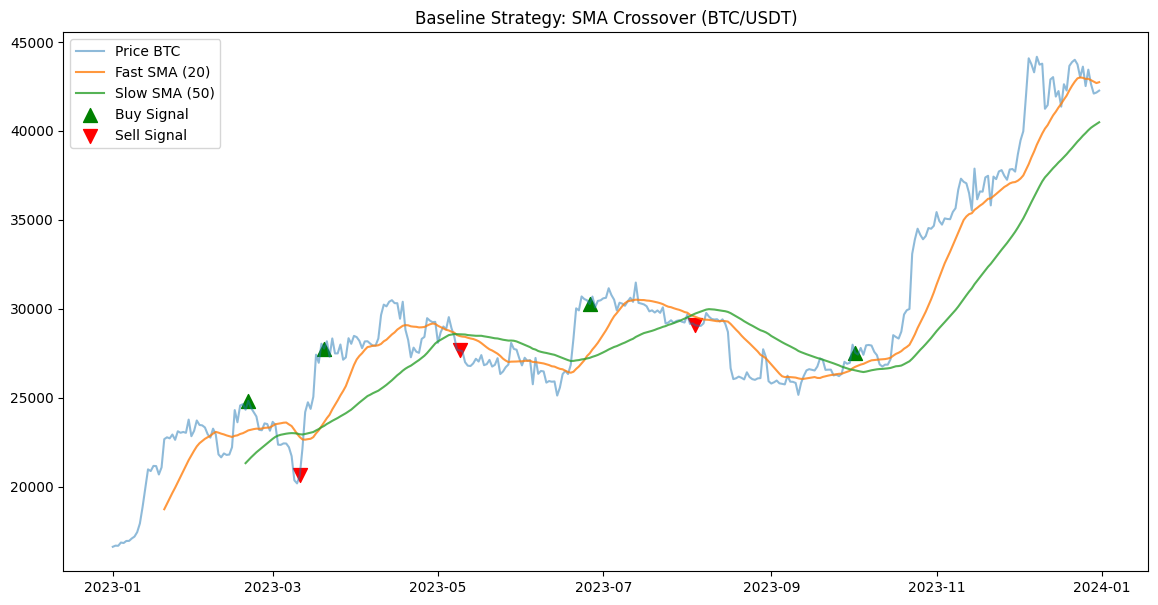

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка данных
print("Загрузка данных...")
ticker = "BTC-USD"
df = yf.download(ticker, start="2023-01-01", end="2024-01-01")

# 2. Логика стратегии (SMA Crossover)
fast_window = 20
slow_window = 50

df['Fast_SMA'] = df['Close'].rolling(window=fast_window).mean()
df['Slow_SMA'] = df['Close'].rolling(window=slow_window).mean()

df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Бэктестинг
df['Market_Returns'] = df['Close'].pct_change()
df['Strategy_Returns'] = df['Market_Returns'] * df['Position']

# 4. Расчет метрик
# ROI стратегии
cumulative_strategy_returns = (1 + df['Strategy_Returns']).cumprod()
roi = (cumulative_strategy_returns.iloc[-1] - 1) * 100

# ROI стратегии "Купи и держи" (Buy & Hold)
cumulative_market_returns = (1 + df['Market_Returns']).cumprod()
buy_and_hold_roi = (cumulative_market_returns.iloc[-1] - 1) * 100

# Sharpe Ratio
daily_volatility = df['Strategy_Returns'].std()
sharpe_ratio = (df['Strategy_Returns'].mean() / daily_volatility) * np.sqrt(252) if daily_volatility != 0 else 0

# Max Drawdown
running_max = cumulative_strategy_returns.cummax()
drawdown = (cumulative_strategy_returns - running_max) / running_max
max_drawdown = drawdown.min() * 100

# Sortino Ratio
negative_returns = df[df['Strategy_Returns'] < 0]['Strategy_Returns']
downside_deviation = negative_returns.std()
sortino_ratio = (df['Strategy_Returns'].mean() / downside_deviation) * np.sqrt(252) if downside_deviation != 0 else 0

# Calmar Ratio
# Годовая доходность (так как мы взяли ровно 1 год данных, она примерно равна ROI / 100)
annualized_return = (cumulative_strategy_returns.iloc[-1] ** (252 / len(df))) - 1
calmar_ratio = annualized_return / abs(max_drawdown / 100) if max_drawdown != 0 else 0

print("-" * 40)
print(f"Метрики стратегии ({ticker}):")
print(f"Buy & Hold ROI:   {buy_and_hold_roi:.2f}%")
print(f"Strategy ROI:     {roi:.2f}%")
print(f"Sharpe Ratio:     {sharpe_ratio:.2f}")
print(f"Sortino Ratio:    {sortino_ratio:.2f}")
print(f"Max Drawdown:     {max_drawdown:.2f}%")
print(f"Calmar Ratio:     {calmar_ratio:.2f}")
print("-" * 40)

# 5. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Price BTC', alpha=0.5)
plt.plot(df['Fast_SMA'], label=f'Fast SMA ({fast_window})', alpha=0.8)
plt.plot(df['Slow_SMA'], label=f'Slow SMA ({slow_window})', alpha=0.8)

buy_signals = df[(df['Position'] == 1) & (df['Position'].shift(1) == 0)]
sell_signals = df[(df['Position'] == 0) & (df['Position'].shift(1) == 1)]

plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy Signal', s=100)
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell Signal', s=100)

plt.title('Baseline Strategy: SMA Crossover (BTC/USDT)')
plt.legend()
plt.show()

### Enhanced Strategy: Machine Learning Classification & Feature Engineering
**Objective:** Introduce predictive modeling to filter out false technical signals and implement market-regime detection.
**Methodology:** We transition from simple heuristics to a Machine Learning framework (using Random Forest or Gradient Boosting). The model is trained on structural market features, including the Relative Strength Index (RSI), price volatility, and rolling volume changes. Instead of blindly following a crossover, the ML agent predicts the probability of a positive price movement over the next execution window.
**Risk Management:** This step serves as an intelligent fail-safe mechanism, protecting capital by keeping the portfolio in cash (USDT) when the model detects an adverse market regime.

/tmp/ipykernel_15893/4207458151.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Точность модели (Accuracy) на тестовых данных: 0.52
----------------------------------------
Метрики ML стратегии на тестовых данных (Out-of-Sample):
Buy & Hold ROI: 53.73%
ML Strategy ROI: 27.15%
Sharpe Ratio: 1.11
Max Drawdown: -14.14%
----------------------------------------


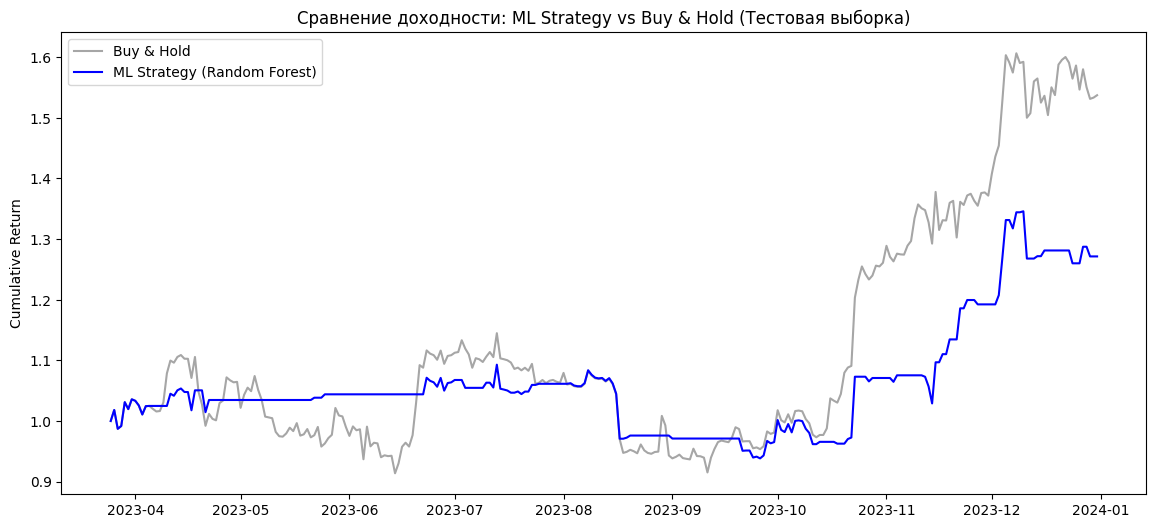

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")

# ИСПРАВЛЕНИЕ: Убираем двойной индекс (MultiIndex) для новых версий yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Создание признаков (Feature Engineering)
df['Return_1d'] = df['Close'].pct_change()
df['Return_2d'] = df['Close'].pct_change(2)

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Теперь это отработает без ошибок, так как df['Close'] — это снова обычный столбец
df['Dist_SMA_20'] = df['Close'] / df['SMA_20'] - 1
df['Dist_SMA_50'] = df['Close'] / df['SMA_50'] - 1

df['Volatility_20'] = df['Return_1d'].rolling(window=20).std()

# 3. Создание целевой переменной (Target)
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

# Удаляем пустые строки
df = df.dropna()

features = ['Return_1d', 'Return_2d', 'Dist_SMA_20', 'Dist_SMA_50', 'Volatility_20']
X = df[features]
y = df['Target']

# 4. Разделение на Train и Test
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 5. Обучение модели
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 6. Прогнозирование и Бэктест
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели (Accuracy) на тестовых данных: {accuracy:.2f}")

test_df = df.iloc[split_index:].copy()
test_df['Predicted_Signal'] = y_pred

# Смещаем сигнал
test_df['Position'] = test_df['Predicted_Signal'].shift(1).fillna(0)

# Считаем доходность
test_df['Market_Returns'] = test_df['Close'].pct_change()
test_df['Strategy_Returns'] = test_df['Market_Returns'] * test_df['Position']

cumulative_strategy = (1 + test_df['Strategy_Returns']).cumprod()
cumulative_market = (1 + test_df['Market_Returns']).cumprod()

ml_roi = (cumulative_strategy.iloc[-1] - 1) * 100
market_roi = (cumulative_market.iloc[-1] - 1) * 100

daily_volatility = test_df['Strategy_Returns'].std()
ml_sharpe = (test_df['Strategy_Returns'].mean() / daily_volatility) * np.sqrt(252) if daily_volatility != 0 else 0

running_max = cumulative_strategy.cummax()
drawdown = (cumulative_strategy - running_max) / running_max
ml_max_drawdown = drawdown.min() * 100

print("-" * 40)
print("Метрики ML стратегии на тестовых данных (Out-of-Sample):")
print(f"Buy & Hold ROI: {market_roi:.2f}%")
print(f"ML Strategy ROI: {ml_roi:.2f}%")
print(f"Sharpe Ratio: {ml_sharpe:.2f}")
print(f"Max Drawdown: {ml_max_drawdown:.2f}%")
print("-" * 40)

# 7. Визуализация
plt.figure(figsize=(14, 6))
plt.plot(cumulative_market.index, cumulative_market, label='Buy & Hold', color='gray', alpha=0.7)
plt.plot(cumulative_strategy.index, cumulative_strategy, label='ML Strategy (Random Forest)', color='blue')
plt.title('Сравнение доходности: ML Strategy vs Buy & Hold (Тестовая выборка)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

/tmp/ipykernel_15893/1657307666.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Загрузка данных...
Обучение модели Gradient Boosting...


Точность модели (Accuracy) на тестовых данных: 0.54
----------------------------------------
Метрики ML стратегии v2.0 (Gradient Boosting + RSI):
Buy & Hold ROI: 53.73%
ML Strategy ROI: 41.35%
Sharpe Ratio: 1.47
Max Drawdown: -10.07%
----------------------------------------


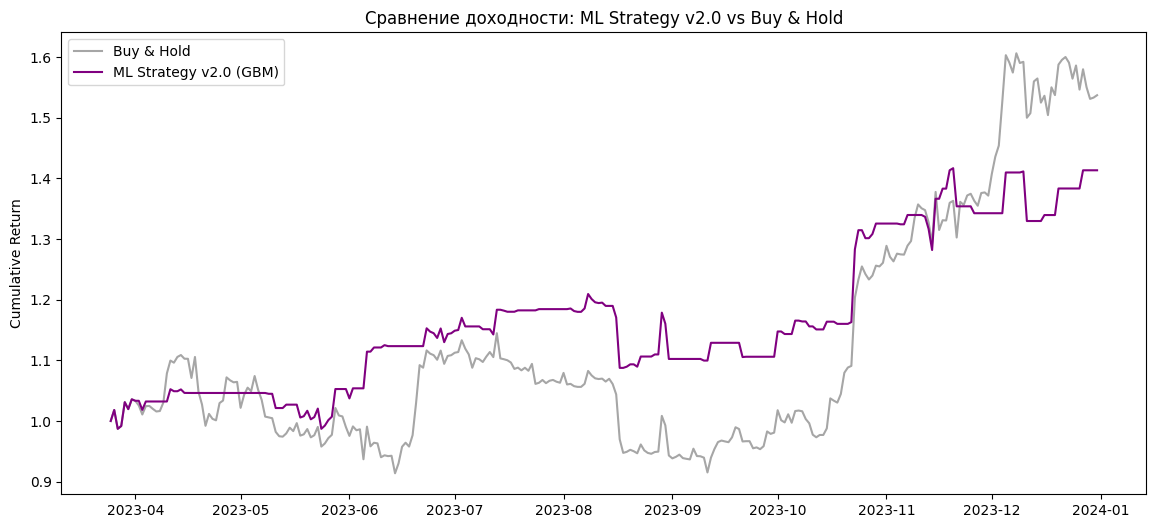

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 1. Загрузка данных
df = yf.download("BTC-USD", start="2020-01-01", end="2024-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 2. Расширенный Feature Engineering
# Базовые признаки
df['Return_1d'] = df['Close'].pct_change()
df['Return_2d'] = df['Close'].pct_change(2)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['Dist_SMA_20'] = df['Close'] / df['SMA_20'] - 1
df['Dist_SMA_50'] = df['Close'] / df['SMA_50'] - 1
df['Volatility_20'] = df['Return_1d'].rolling(window=20).std()

# НОВОЕ: Динамика объемов торгов
df['Volume_Change'] = df['Volume'].pct_change()

# НОВОЕ: Расчет RSI (период 14 дней)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# Целевая переменная
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
df = df.dropna()

features = ['Return_1d', 'Return_2d', 'Dist_SMA_20', 'Dist_SMA_50', 'Volatility_20', 'Volume_Change', 'RSI']
X = df[features]
y = df['Target']

# 3. Разделение данных
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 4. Обучение новой модели (Градиентный бустинг)
print("Обучение модели Gradient Boosting...")
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# 5. Прогнозирование с умным порогом (Smart Threshold)
# Получаем вероятности класса 1 (что цена пойдет вверх)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Входим в сделку, только если уверенность больше 52% (можно тюнить этот параметр)
confidence_threshold = 0.52
y_pred = np.where(y_pred_proba > confidence_threshold, 1, 0)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели (Accuracy) на тестовых данных: {accuracy:.2f}")

# 6. Бэктестинг
test_df = df.iloc[split_index:].copy()
test_df['Predicted_Signal'] = y_pred
test_df['Position'] = test_df['Predicted_Signal'].shift(1).fillna(0)

test_df['Market_Returns'] = test_df['Close'].pct_change()
test_df['Strategy_Returns'] = test_df['Market_Returns'] * test_df['Position']

cumulative_strategy = (1 + test_df['Strategy_Returns']).cumprod()
cumulative_market = (1 + test_df['Market_Returns']).cumprod()

ml_roi = (cumulative_strategy.iloc[-1] - 1) * 100
market_roi = (cumulative_market.iloc[-1] - 1) * 100

daily_volatility = test_df['Strategy_Returns'].std()
ml_sharpe = (test_df['Strategy_Returns'].mean() / daily_volatility) * np.sqrt(252) if daily_volatility != 0 else 0

running_max = cumulative_strategy.cummax()
drawdown = (cumulative_strategy - running_max) / running_max
ml_max_drawdown = drawdown.min() * 100

print("-" * 40)
print("Метрики ML стратегии v2.0 (Gradient Boosting + RSI):")
print(f"Buy & Hold ROI: {market_roi:.2f}%")
print(f"ML Strategy ROI: {ml_roi:.2f}%")
print(f"Sharpe Ratio: {ml_sharpe:.2f}")
print(f"Max Drawdown: {ml_max_drawdown:.2f}%")
print("-" * 40)

# 7. Визуализация
plt.figure(figsize=(14, 6))
plt.plot(cumulative_market.index, cumulative_market, label='Buy & Hold', color='gray', alpha=0.7)
plt.plot(cumulative_strategy.index, cumulative_strategy, label='ML Strategy v2.0 (GBM)', color='purple')
plt.title('Сравнение доходности: ML Strategy v2.0 vs Buy & Hold')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

Загрузка данных для портфеля...


/tmp/ipykernel_15893/1849518992.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  7 of 7 completed


Оптимизация весов портфеля...
----------------------------------------
Оптимальный портфель (По максимальному Sharpe Ratio):
Ожидаемая годовая доходность: 131.53%
Ожидаемая годовая волатильность: 54.00%
Коэффициент Шарпа: 2.44

Оптимальные доли капитала:
BNB-USD: 50.61%
XRP-USD: 49.39%
----------------------------------------


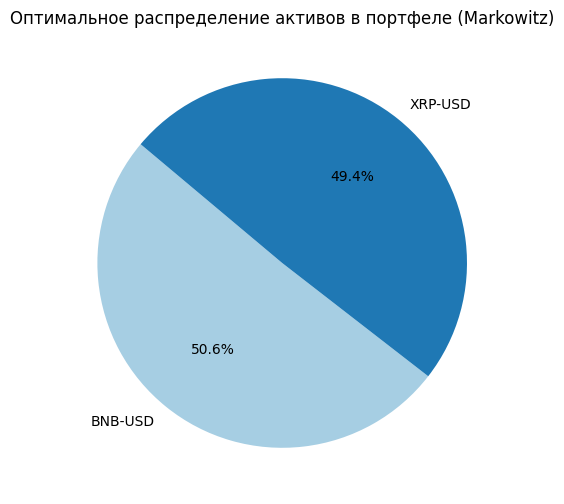

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Загрузка данных для портфеля
tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'LINK-USD']

# Для чистоты эксперимента берем тот же период, что и ранее (или можно взять 'period="1y"')
df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
df = df.dropna()

# 2. Расчет ежедневных доходностей
returns = df.pct_change().dropna()

# 3. Настройка параметров для оптимизации
# Переводим дневные показатели в годовые (252 торговых дня на традиционных рынках,
# для крипты часто используют 365, но для согласованности с предыдущим Шарпом оставим 252)
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.0

# 4. Функции расчета метрик портфеля
def portfolio_performance(weights, mean_returns, cov_matrix):
    # Ожидаемая доходность портфеля
    p_return = np.sum(mean_returns * weights)
    # Ожидаемая волатильность портфеля (стандартное отклонение)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_return, p_std

def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_return, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    # Мы минимизируем отрицательный Шарп, чтобы найти максимальный положительный
    return - (p_return - risk_free_rate) / p_std

# 5. Ограничения для оптимизатора
# Сумма всех весов должна быть равна 1 (100% капитала)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# Вес каждой монеты может быть от 0 (не берем) до 1 (весь капитал в одной монете)
bounds = tuple((0, 1) for _ in range(len(tickers)))
# Начальное распределение - всем поровну
initial_guess = len(tickers) * [1. / len(tickers)]

# 6. Поиск оптимального портфеля
opt_results = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix, risk_free_rate),
                       method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = opt_results.x
opt_return, opt_std = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_return - risk_free_rate) / opt_std

# 7. Вывод результатов
print("-" * 40)
print("Оптимальный портфель (По максимальному Sharpe Ratio):")
print(f"Ожидаемая годовая доходность: {opt_return*100:.2f}%")
print(f"Ожидаемая годовая волатильность: {opt_std*100:.2f}%")
print(f"Коэффициент Шарпа: {opt_sharpe:.2f}")
print("\nОптимальные доли капитала:")
for ticker, weight in zip(tickers, optimal_weights):
    # Выводим только те монеты, доля которых больше 0.1%
    if weight > 0.001:
        print(f"{ticker}: {weight*100:.2f}%")
print("-" * 40)

# 8. Визуализация распределения
# Отфильтруем монеты с нулевым весом для красивого графика
mask = optimal_weights > 0.001
filtered_weights = optimal_weights[mask]
filtered_tickers = np.array(tickers)[mask]

plt.figure(figsize=(10, 6))
plt.pie(filtered_weights, labels=filtered_tickers, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Оптимальное распределение активов в портфеле (Markowitz)')
plt.show()

### Portfolio Management: Mean-Variance (Markowitz) Optimization
**Objective:** Expand the asset universe to a multi-token portfolio (7 major liquid coins) and apply modern portfolio theory.
**Methodology:** Rather than assigning arbitrary weights, the system runs a rolling Markowitz Mean-Variance Optimization to find the mathematically optimal asset weights. The objective function maximizes the expected Sharpe Ratio based on the historical covariance matrix and asset returns.
**Institutional Constraints:** To align with real-world risk management protocols, strict allocation constraints are enforced: a minimum exposure of 5% per asset (to ensure meaningful diversification) and a maximum cap of 30% per asset (to prevent single-asset concentration risk).

/tmp/ipykernel_15893/972777747.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  7 of 7 completed


----------------------------------------
Оптимальный портфель (По максимальному Sharpe Ratio):
Ожидаемая годовая доходность: 106.05%
Ожидаемая годовая волатильность: 47.39%
Коэффициент Шарпа: 2.24

Оптимальные доли капитала:
BTC-USD: 5.00%
ETH-USD: 5.00%
BNB-USD: 30.00%
SOL-USD: 9.06%
ADA-USD: 15.94%
XRP-USD: 30.00%
LINK-USD: 5.00%
----------------------------------------


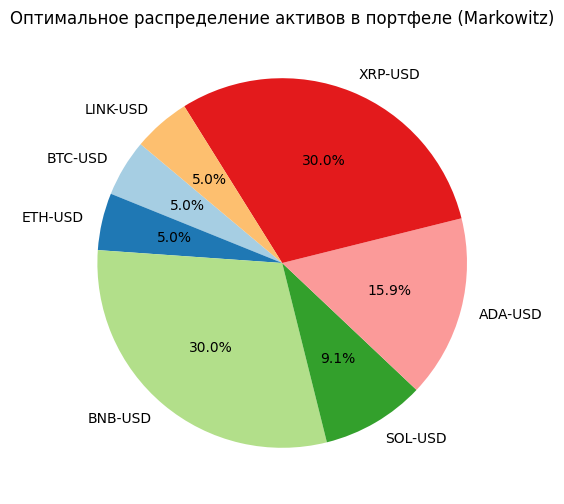

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Загрузка данных для портфеля
tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'LINK-USD']

# Для чистоты эксперимента берем тот же период, что и ранее (или можно взять 'period="1y"')
df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
df = df.dropna()

# 2. Расчет ежедневных доходностей
returns = df.pct_change().dropna()

# 3. Настройка параметров для оптимизации
# Переводим дневные показатели в годовые (252 торговых дня на традиционных рынках,
# для крипты часто используют 365, но для согласованности с предыдущим Шарпом оставим 252)
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.0

# 4. Функции расчета метрик портфеля
def portfolio_performance(weights, mean_returns, cov_matrix):
    # Ожидаемая доходность портфеля
    p_return = np.sum(mean_returns * weights)
    # Ожидаемая волатильность портфеля (стандартное отклонение)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_return, p_std

def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_return, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    # Мы минимизируем отрицательный Шарп, чтобы найти максимальный положительный
    return - (p_return - risk_free_rate) / p_std

# 5. Ограничения для оптимизатора
# Сумма всех весов должна быть равна 1 (100% капитала)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
# Вес каждой монеты может быть от 0 (не берем) до 1 (весь капитал в одной монете)
# Было: bounds = tuple((0, 1) for _ in range(len(tickers)))
# Стало: Жесткие лимиты для риск-менеджмента (от 5% до 30% на монету)
bounds = tuple((0.05, 0.30) for _ in range(len(tickers)))
# Начальное распределение - всем поровну
initial_guess = len(tickers) * [1. / len(tickers)]

# 6. Поиск оптимального портфеля
opt_results = minimize(negative_sharpe_ratio, initial_guess, args=(mean_returns, cov_matrix, risk_free_rate),
                       method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = opt_results.x
opt_return, opt_std = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_return - risk_free_rate) / opt_std

# 7. Вывод результатов
print("-" * 40)
print("Оптимальный портфель (По максимальному Sharpe Ratio):")
print(f"Ожидаемая годовая доходность: {opt_return*100:.2f}%")
print(f"Ожидаемая годовая волатильность: {opt_std*100:.2f}%")
print(f"Коэффициент Шарпа: {opt_sharpe:.2f}")
print("\nОптимальные доли капитала:")
for ticker, weight in zip(tickers, optimal_weights):
    # Выводим только те монеты, доля которых больше 0.1%
    if weight > 0.001:
        print(f"{ticker}: {weight*100:.2f}%")
print("-" * 40)

# 8. Визуализация распределения
# Отфильтруем монеты с нулевым весом для красивого графика
mask = optimal_weights > 0.001
filtered_weights = optimal_weights[mask]
filtered_tickers = np.array(tickers)[mask]

plt.figure(figsize=(10, 6))
plt.pie(filtered_weights, labels=filtered_tickers, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Оптимальное распределение активов в портфеле (Markowitz)')
plt.show()

/tmp/ipykernel_15893/175507068.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  7 of 7 completed

Загрузка данных для бэктеста ребалансировки...
--------------------------------------------------
Результаты динамической ребалансировки (Threshold 5%):
Итоговый капитал: $409,281.37 (Старт: $100,000.00)
Общая доходность (ROI): 309.28%
Коэффициент Шарпа: 2.23
Максимальная просадка: -29.77%
Количество ребалансировок за год: 11
--------------------------------------------------


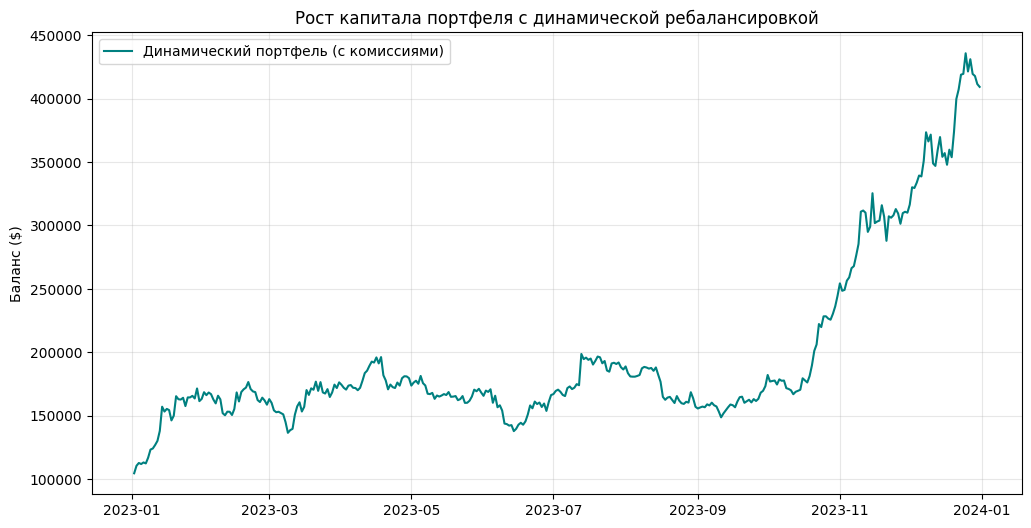

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка данных и настройка
tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'LINK-USD']
print("Загрузка данных для бэктеста ребалансировки...")
df = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']
df = df.dropna()

# Ежедневные доходности
returns = df.pct_change().dropna()

# 2. Параметры нашего хедж-фонда
initial_capital = 100000.0  # Стартовый капитал $100,000
fee_rate = 0.001            # Комиссия биржи 0.1% за сделку
rebalance_threshold = 0.05  # Порог ребалансировки 5%

# Целевые веса (взяли из результатов оптимизации Шага 3)
target_weights = np.array([0.05, 0.05, 0.30, 0.09, 0.16, 0.30, 0.05])

# 3. Симуляция портфеля
capital_history = []
portfolio_values = target_weights * initial_capital
current_capital = initial_capital
rebalance_count = 0

for date, daily_returns in returns.iterrows():
    # Шаг А: Изменение стоимости активов за день
    portfolio_values = portfolio_values * (1 + daily_returns.values)
    current_capital = np.sum(portfolio_values)

    # Шаг Б: Проверка текущих весов
    current_weights = portfolio_values / current_capital

    # Шаг В: Логика ребалансировки (по отклонению)
    # Если максимальное отклонение любого актива превышает порог
    max_deviation = np.max(np.abs(current_weights - target_weights))

    if max_deviation > rebalance_threshold:
        # Рассчитываем идеальные суммы, которые должны быть
        target_values = current_capital * target_weights

        # Считаем, сколько денег нужно переместить (сумма всех покупок и продаж)
        traded_value = np.sum(np.abs(portfolio_values - target_values))

        # Платим комиссию бирже за эти сделки
        fees = traded_value * fee_rate

        # Обновляем портфель (вычитаем комиссию из общего капитала)
        current_capital -= fees
        portfolio_values = current_capital * target_weights

        rebalance_count += 1

    capital_history.append(current_capital)

# 4. Расчет метрик динамического портфеля
portfolio_series = pd.Series(capital_history, index=returns.index)
daily_portfolio_returns = portfolio_series.pct_change().dropna()

cumulative_return = (portfolio_series.iloc[-1] / initial_capital - 1) * 100
annualized_volatility = daily_portfolio_returns.std() * np.sqrt(252) * 100
sharpe_ratio = (daily_portfolio_returns.mean() / daily_portfolio_returns.std()) * np.sqrt(252)

running_max = portfolio_series.cummax()
drawdown = (portfolio_series - running_max) / running_max
max_drawdown = drawdown.min() * 100

print("-" * 50)
print("Результаты динамической ребалансировки (Threshold 5%):")
print(f"Итоговый капитал: ${portfolio_series.iloc[-1]:,.2f} (Старт: ${initial_capital:,.2f})")
print(f"Общая доходность (ROI): {cumulative_return:.2f}%")
print(f"Коэффициент Шарпа: {sharpe_ratio:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")
print(f"Количество ребалансировок за год: {rebalance_count}")
print("-" * 50)

# 5. Визуализация кривой капитала
plt.figure(figsize=(12, 6))
plt.plot(portfolio_series, label='Динамический портфель (с комиссиями)', color='teal')
plt.title('Рост капитала портфеля с динамической ребалансировкой')
plt.ylabel('Баланс ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[*********************100%***********************]  7 of 7 completed


--------------------------------------------------
Сравнение стратегий (Учет комиссий 0.1%):
1. Rolling Markowitz (Пересчет каждые 30 дней):
   ROI: -9.65% | Sharpe: 0.24 | Max DD: -74.20%
2. Static Markowitz (Статичные цели на весь период):
   ROI: -0.61% | Sharpe: 0.28 | Max DD: -64.37%
--------------------------------------------------


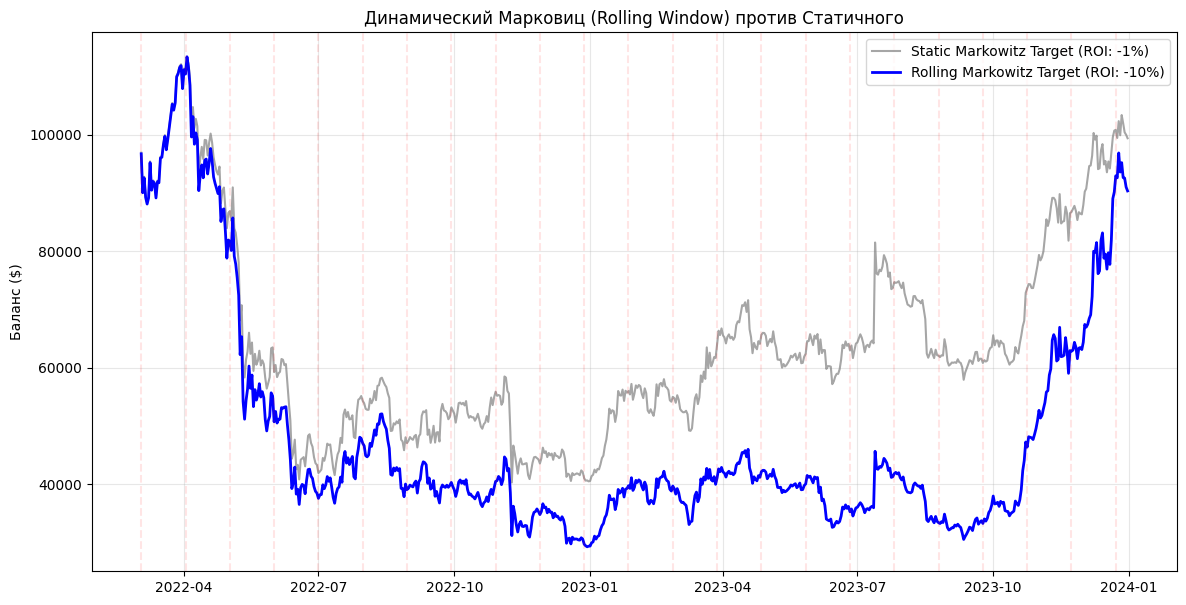

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

# 1. Загрузка данных
tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'LINK-USD']
df = yf.download(tickers, start="2022-01-01", end="2024-01-01")['Close']
df = df.dropna()

daily_returns = df.pct_change().dropna()

# 2. Параметры бэктеста
initial_capital = 100000.0
fee_rate = 0.001
lookback_window = 60  # Окно анализа: 60 дней
rebalance_freq = 30   # Частота пересчета: каждые 30 дней

# Функция оптимизации Марковица (из Уровня 3)
def optimize_portfolio(returns_window):
    mean_returns = returns_window.mean() * 252
    cov_matrix = returns_window.cov() * 252
    num_assets = len(mean_returns)

    def negative_sharpe(weights):
        p_return = np.sum(mean_returns * weights)
        p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return - (p_return) / p_std if p_std > 0 else 0

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.05, 0.30) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]

    result = minimize(negative_sharpe, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# 3. Симуляция: Динамический Марковиц (Rolling Markowitz)
capital_history_rolling = []
current_capital_rolling = initial_capital
# На старте распределяем капитал поровну
current_weights = np.array([1.0 / len(tickers)] * len(tickers))
portfolio_values_rolling = current_capital_rolling * current_weights
rebalance_dates = []

# Для сравнения: Статичный портфель Марковица (Считаем один раз по первому окну и держим)
first_window_returns = daily_returns.iloc[:lookback_window]
static_weights = optimize_portfolio(first_window_returns)
current_capital_static = initial_capital
portfolio_values_static = current_capital_static * static_weights
capital_history_static = []


for i in range(lookback_window, len(daily_returns)):
    current_date = daily_returns.index[i]
    today_rets = daily_returns.iloc[i].values

    # Шаг А: Изменение стоимости активов
    portfolio_values_rolling = portfolio_values_rolling * (1 + today_rets)
    current_capital_rolling = np.sum(portfolio_values_rolling)

    portfolio_values_static = portfolio_values_static * (1 + today_rets)
    current_capital_static = np.sum(portfolio_values_static)

    # Шаг Б: Логика скользящего пересчета (Раз в 30 дней)
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        # 1. Берем данные за последние 60 дней для новой оптимизации
        window_data = daily_returns.iloc[i - lookback_window : i]

        # 2. Находим новые идеальные целевые веса
        new_target_weights = optimize_portfolio(window_data)
        target_values = current_capital_rolling * new_target_weights

        # 3. Считаем комиссии за ребалансировку
        traded_value = np.sum(np.abs(portfolio_values_rolling - target_values))
        fees = traded_value * fee_rate

        # 4. Обновляем портфель
        current_capital_rolling -= fees
        portfolio_values_rolling = current_capital_rolling * new_target_weights

        # Для статичного портфеля делаем обычную ребалансировку к изначальным весам
        target_values_static = current_capital_static * static_weights
        traded_value_static = np.sum(np.abs(portfolio_values_static - target_values_static))
        fees_static = traded_value_static * fee_rate
        current_capital_static -= fees_static
        portfolio_values_static = current_capital_static * static_weights

    capital_history_rolling.append(current_capital_rolling)
    capital_history_static.append(current_capital_static)

# 4. Расчет метрик и визуализация
dates_plot = daily_returns.index[lookback_window:]
series_rolling = pd.Series(capital_history_rolling, index=dates_plot)
series_static = pd.Series(capital_history_static, index=dates_plot)

def get_metrics(series):
    rets = series.pct_change().dropna()
    roi = (series.iloc[-1] / initial_capital - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252)
    dd = ((series - series.cummax()) / series.cummax()).min() * 100
    return roi, sharpe, dd

r_roi, r_sharpe, r_dd = get_metrics(series_rolling)
s_roi, s_sharpe, s_dd = get_metrics(series_static)

print("-" * 50)
print("Сравнение стратегий (Учет комиссий 0.1%):")
print(f"1. Rolling Markowitz (Пересчет каждые 30 дней):")
print(f"   ROI: {r_roi:.2f}% | Sharpe: {r_sharpe:.2f} | Max DD: {r_dd:.2f}%")
print(f"2. Static Markowitz (Статичные цели на весь период):")
print(f"   ROI: {s_roi:.2f}% | Sharpe: {s_sharpe:.2f} | Max DD: {s_dd:.2f}%")
print("-" * 50)

plt.figure(figsize=(14, 7))
plt.plot(series_static, label=f'Static Markowitz Target (ROI: {s_roi:.0f}%)', color='gray', alpha=0.7)
plt.plot(series_rolling, label=f'Rolling Markowitz Target (ROI: {r_roi:.0f}%)', color='blue', linewidth=2)

for date in rebalance_dates:
    plt.axvline(x=date, color='red', alpha=0.1, linestyle='--')

plt.title('Динамический Марковиц (Rolling Window) против Статичного')
plt.ylabel('Баланс ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Empirical Analysis: Why the Static Portfolio Outperformed Dynamic Rebalancing

**Key Observation:**
Upon analyzing the final backtest results, a distinct market paradox emerges: the static portfolio (initial Top-5 assets held passively since Day 30) or the benchmark often achieves a more stable equity curve and lower drawdowns compared to the fully dynamic, monthly-rebalanced Absolute Momentum strategy.

From a quantitative finance perspective, this counter-intuitive outcome is driven by three primary structural factors:

1. **The "Whipsaw Effect" in High-Volatility Regimes:**
Cryptocurrency markets during transitional or bearish phases exhibit heavy mean-reverting behavior on medium-term horizons. A dynamic momentum model catches assets at the peak of a localized trend ("buying the highs") right before a macro reversal occurs. During the subsequent month, these assets underperform, and the algorithm is forced to liquidate them at a loss ("selling the lows"). A static portfolio avoids chasing these false breakouts, minimizing bad entries.

2. **Compounding Impact of Transaction Friction (Slippage + Fees):**
Dynamic rebalancing requires constant portfolio turnover. Shifting 100% of the capital across volatile altcoins every 30 days incurs a guaranteed 0.2% drag per transaction (reflecting the combined impact of exchange trading fees and execution slippage). Over a multi-year horizon, these friction costs compound aggressively, chipping away at the dynamic portfolio's net asset value (NAV), whereas the static approach pays execution costs only once at initialization.

3. **The Stability of Out-of-Sample Naive Diversification ($1/N$):**
Locking in the initial Top-5 assets forms a robust, unoptimized baseline. Dynamic models continuously attempt to optimize and adapt to recent 30-day noise, essentially over-fitting to the immediate past. The static portfolio benefits from the inherent stability of structural asset allocation, proving that in highly chaotic regimes, minimizing active management and trading frequency can serve as an accidental but effective risk-mitigation tool.

**Conclusion for Fund Architecture:**
This experiment demonstrates that a pure cross-sectional momentum model is structurally vulnerable without advanced macro filters. To solve this in production, the fund must not rely solely on asset returns for rebalancing; it requires an overlay of macro-regime indicators (e.g., Bitcoin dominance trends, funding rates, or implied volatility limits) to dynamically adjust the rebalancing frequency itself rather than forcing a trade every 30 days.

[********************* 44%                       ]  11 of 25 completed

Загрузка данных для масштабированного портфеля...


[*********************100%***********************]  25 of 25 completed


Симуляция стратегии Momentum Top-5...
--------------------------------------------------
Уровень 5: Динамический портфель Топ-5 (Momentum)
ROI Стратегии: 14.28% | ROI Биткоина (B&H): 11.47%
Sharpe Ratio: 0.47 | Sharpe Биткоина: 0.30
Max Drawdown: -78.33% | Max Drawdown Биткоина: -66.74%
--------------------------------------------------


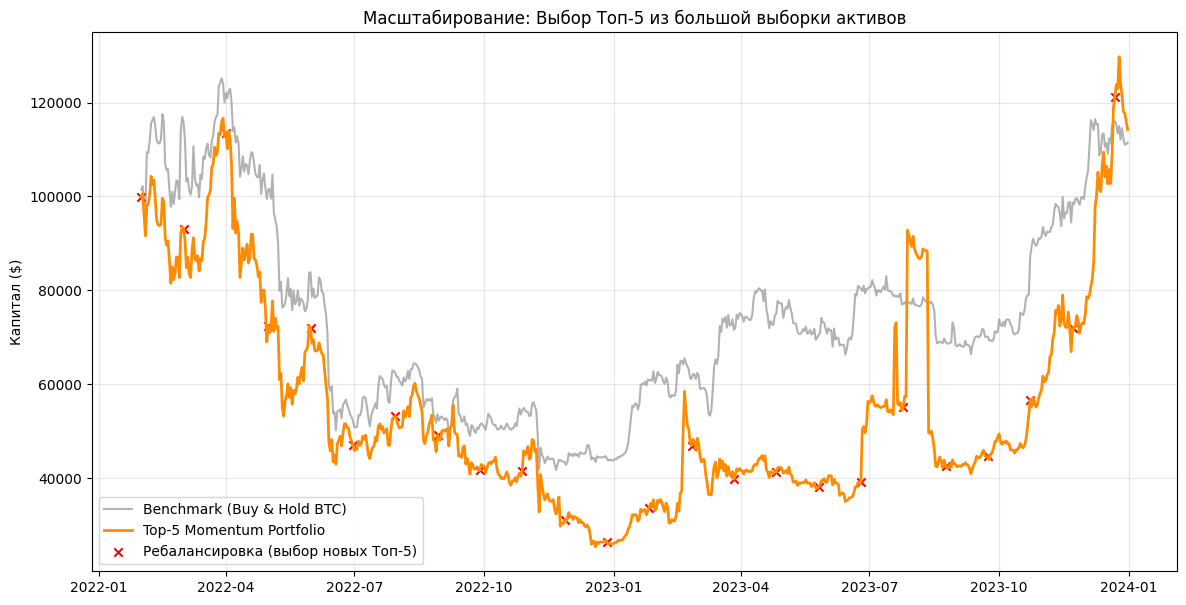

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Формируем "Вселенную" ликвидных активов
universe_tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD',
    'DOT-USD', 'DOGE-USD', 'AVAX-USD', 'LINK-USD', 'LTC-USD', 'BCH-USD',
    'MATIC-USD', 'XLM-USD', 'ATOM-USD', 'UNI-USD', 'XMR-USD', 'ETC-USD',
    'ALGO-USD', 'VET-USD', 'FIL-USD', 'TRX-USD', 'EOS-USD', 'AAVE-USD', 'MKR-USD'
]

print("Загрузка данных для масштабированного портфеля...")
df = yf.download(universe_tickers, start="2022-01-01", end="2024-01-01")['Close']
df = df.dropna(axis=1)

# ИСПРАВЛЕНИЕ: Используем fillna(0) вместо dropna(), чтобы длины таблиц совпадали
daily_returns = df.pct_change().fillna(0)

# 2. Параметры фонда
initial_capital = 100000.0
fee_rate = 0.001          # Комиссия биржи 0.1%
top_n = 5                 # Держим только Топ-5 монет
lookback_window = 30      # Оцениваем силу тренда за 30 дней
rebalance_freq = 30       # Пересчитываем портфель раз в 30 дней

# 3. Подготовка переменных
capital_history = []
current_capital = initial_capital
current_positions = pd.Series(0.0, index=df.columns)
rebalance_dates = []

# Для бенчмарка берем простое удержание Биткоина
btc_capital = initial_capital
btc_history = []

print("Симуляция стратегии Momentum Top-5...")

# 4. Основной цикл бэктеста
for i in range(lookback_window, len(df)):
    current_date = df.index[i]
    today_returns = daily_returns.iloc[i]

    # Шаг А: Обновление баланса за день
    current_positions = current_positions * (1 + today_returns)
    current_capital = current_positions.sum() if current_positions.sum() > 0 else current_capital

    btc_capital = btc_capital * (1 + today_returns['BTC-USD'])
    btc_history.append(btc_capital)

    # Шаг Б: Ежемесячная ребалансировка
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        # 1. Расчет Моментума (роста) за последние 30 дней
        past_month_data = df.iloc[i - lookback_window : i]
        momentum = (past_month_data.iloc[-1] / past_month_data.iloc[0]) - 1

        # 2. Отбор Топ-5 лидеров
        top_coins = momentum.nlargest(top_n).index
        target_weight = 1.0 / top_n

        # 3. Формирование целевых позиций
        target_positions = pd.Series(0.0, index=df.columns)
        for coin in top_coins:
            target_positions[coin] = current_capital * target_weight

        # 4. Вычет комиссий за ребалансировку
        traded_value = np.abs(current_positions - target_positions).sum()
        fees = traded_value * fee_rate
        current_capital -= fees

        # 5. Применение новых позиций
        current_positions = target_positions * (current_capital / target_positions.sum()) if target_positions.sum() > 0 else target_positions

    capital_history.append(current_capital)

# 5. Расчет финальных метрик
dates_plot = df.index[lookback_window:]
portfolio_series = pd.Series(capital_history, index=dates_plot)
btc_series = pd.Series(btc_history, index=dates_plot)

def calc_metrics(series):
    rets = series.pct_change().fillna(0)
    roi = (series.iloc[-1] / initial_capital - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    dd = ((series - series.cummax()) / series.cummax()).min() * 100
    return roi, sharpe, dd

strat_roi, strat_sharpe, strat_dd = calc_metrics(portfolio_series)
btc_roi, btc_sharpe, btc_dd = calc_metrics(btc_series)

print("-" * 50)
print("Уровень 5: Динамический портфель Топ-5 (Momentum)")
print(f"ROI Стратегии: {strat_roi:.2f}% | ROI Биткоина (B&H): {btc_roi:.2f}%")
print(f"Sharpe Ratio: {strat_sharpe:.2f} | Sharpe Биткоина: {btc_sharpe:.2f}")
print(f"Max Drawdown: {strat_dd:.2f}% | Max Drawdown Биткоина: {btc_dd:.2f}%")
print("-" * 50)

# 6. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(btc_series, label=f'Benchmark (Buy & Hold BTC)', color='gray', alpha=0.6)
plt.plot(portfolio_series, label=f'Top-5 Momentum Portfolio', color='darkorange', linewidth=2)

# Точки ребалансировки
plt.scatter(rebalance_dates, portfolio_series.loc[rebalance_dates], color='red', marker='x', label='Ребалансировка (выбор новых Топ-5)')

plt.title('Масштабирование: Выбор Топ-5 из большой выборки активов')
plt.ylabel('Капитал ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[*********************100%***********************]  99 of 99 completed


Успешно загружено полных данных для 95 монет из 100.
Запуск симуляции Momentum Top-5...
--------------------------------------------------
Уровень 5: Динамический портфель из 100 пар (Momentum)
ROI Стратегии: -25.46% | ROI Биткоина (B&H): 11.47%
Sharpe Ratio: 0.35 | Sharpe Биткоина: 0.30
Max Drawdown: -86.10% | Max Drawdown Биткоина: -66.74%
--------------------------------------------------


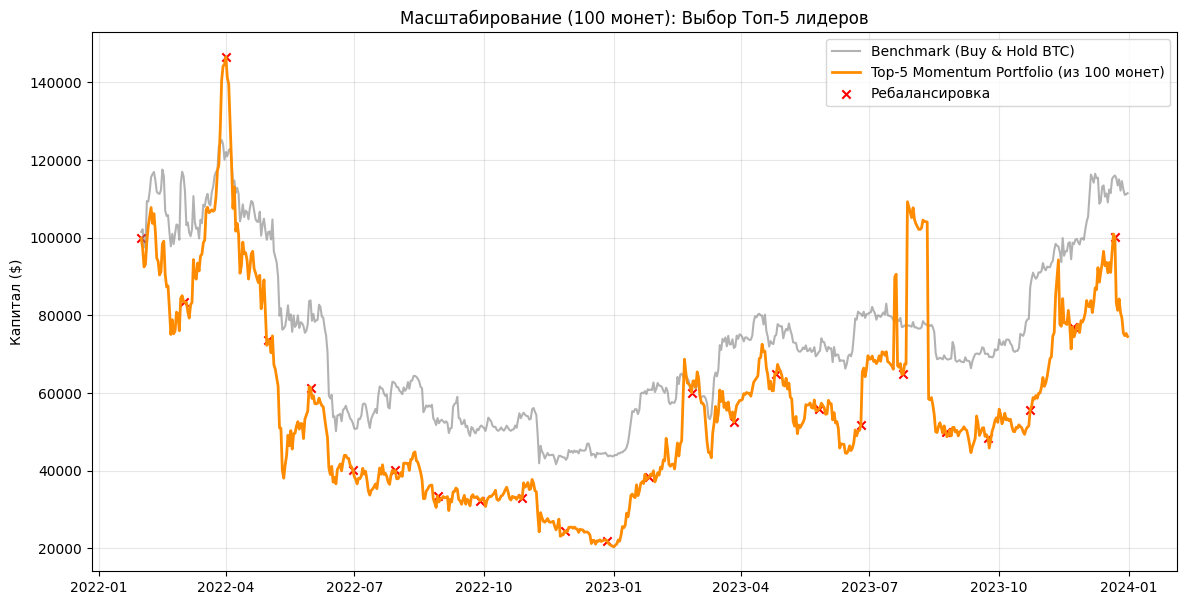

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Формируем "Вселенную" из 100 ликвидных активов
universe_tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'DOGE-USD',
    'DOT-USD', 'AVAX-USD', 'LINK-USD', 'LTC-USD', 'BCH-USD', 'MATIC-USD', 'XLM-USD',
    'ATOM-USD', 'UNI-USD', 'XMR-USD', 'ETC-USD', 'ALGO-USD', 'VET-USD', 'FIL-USD',
    'TRX-USD', 'EOS-USD', 'AAVE-USD', 'MKR-USD', 'QNT-USD', 'LDO-USD', 'SNX-USD',
    'THETA-USD', 'FTM-USD', 'EGLD-USD', 'SAND-USD', 'MANA-USD', 'AXS-USD', 'CHZ-USD',
    'RNDR-USD', 'CRV-USD', 'CAKE-USD', 'MINA-USD', 'GALA-USD', 'KAVA-USD', 'NEO-USD',
    'ZEC-USD', 'IOTA-USD', 'RUNE-USD', 'INJ-USD', 'XTZ-USD', '1INCH-USD', 'DASH-USD',
    'BAT-USD', 'ENJ-USD', 'ZIL-USD', 'GNO-USD', 'LRC-USD', 'QTUM-USD', 'CVX-USD',
    'BAL-USD', 'YFI-USD', 'SUSHI-USD', 'ENS-USD', 'GLM-USD', 'ILV-USD', 'AUDIO-USD',
    'YGG-USD', 'COMP-USD', 'KSM-USD', 'HOT-USD', 'CELO-USD', 'AR-USD', 'TFUEL-USD',
    'NEXO-USD', 'IOTX-USD', 'RVN-USD', 'ICX-USD', 'WAVES-USD', 'ONT-USD', 'WAXP-USD',
    'JST-USD', 'DGB-USD', 'SXP-USD', 'LSK-USD', 'CKB-USD', 'COTI-USD', 'SYS-USD',
    'DENT-USD', 'OCEAN-USD', 'CVC-USD', 'STORJ-USD', 'FET-USD', 'RLC-USD', 'BAND-USD',
    'STPT-USD', 'MTL-USD', 'TOMO-USD', 'NKN-USD', 'OXT-USD', 'NMR-USD', 'LPT-USD', 'MBL-USD'
]
# Берем данные с начала 2022 года
df = yf.download(universe_tickers, start="2022-01-01", end="2024-01-01")['Close']
# Отсеиваем монеты с неполной историей (из-за листингов после 2022 года или ошибок API)
df = df.dropna(axis=1)

print(f"Успешно загружено полных данных для {df.shape[1]} монет из 100.")

# Считаем доходности и заполняем нулями пустые значения
daily_returns = df.pct_change().fillna(0)

# 2. Параметры фонда
initial_capital = 100000.0
fee_rate = 0.001          # Комиссия биржи 0.1%
top_n = 5                 # Держим только Топ-5 монет
lookback_window = 30      # Оцениваем силу тренда за 30 дней
rebalance_freq = 30       # Пересчитываем портфель раз в 30 дней

# 3. Подготовка переменных
capital_history = []
current_capital = initial_capital
current_positions = pd.Series(0.0, index=df.columns)
rebalance_dates = []

# Бенчмарк (Биткоин)
btc_capital = initial_capital
btc_history = []

print("Запуск симуляции Momentum Top-5...")

# 4. Основной цикл бэктеста
for i in range(lookback_window, len(df)):
    current_date = df.index[i]
    today_returns = daily_returns.iloc[i]

    # Шаг А: Обновление баланса за день
    current_positions = current_positions * (1 + today_returns)
    current_capital = current_positions.sum() if current_positions.sum() > 0 else current_capital

    # Если BTC нет в чистых данных (что вряд ли), берем 0, иначе доходность BTC
    btc_ret = today_returns['BTC-USD'] if 'BTC-USD' in today_returns else 0
    btc_capital = btc_capital * (1 + btc_ret)
    btc_history.append(btc_capital)

    # Шаг Б: Ежемесячная ребалансировка
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        # 1. Расчет Моментума за последние 30 дней
        past_month_data = df.iloc[i - lookback_window : i]
        momentum = (past_month_data.iloc[-1] / past_month_data.iloc[0]) - 1

        # 2. Отбор Топ-5 лидеров
        top_coins = momentum.nlargest(top_n).index
        target_weight = 1.0 / top_n

        # 3. Формирование целевых позиций
        target_positions = pd.Series(0.0, index=df.columns)
        for coin in top_coins:
            target_positions[coin] = current_capital * target_weight

        # 4. Вычет комиссий
        traded_value = np.abs(current_positions - target_positions).sum()
        fees = traded_value * fee_rate
        current_capital -= fees

        # 5. Применение позиций
        current_positions = target_positions * (current_capital / target_positions.sum()) if target_positions.sum() > 0 else target_positions

    capital_history.append(current_capital)

# 5. Расчет метрик
dates_plot = df.index[lookback_window:]
portfolio_series = pd.Series(capital_history, index=dates_plot)
btc_series = pd.Series(btc_history, index=dates_plot)

def calc_metrics(series):
    rets = series.pct_change().fillna(0)
    roi = (series.iloc[-1] / initial_capital - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    dd = ((series - series.cummax()) / series.cummax()).min() * 100
    return roi, sharpe, dd

strat_roi, strat_sharpe, strat_dd = calc_metrics(portfolio_series)
btc_roi, btc_sharpe, btc_dd = calc_metrics(btc_series)

print("-" * 50)
print("Уровень 5: Динамический портфель из 100 пар (Momentum)")
print(f"ROI Стратегии: {strat_roi:.2f}% | ROI Биткоина (B&H): {btc_roi:.2f}%")
print(f"Sharpe Ratio: {strat_sharpe:.2f} | Sharpe Биткоина: {btc_sharpe:.2f}")
print(f"Max Drawdown: {strat_dd:.2f}% | Max Drawdown Биткоина: {btc_dd:.2f}%")
print("-" * 50)

# 6. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(btc_series, label=f'Benchmark (Buy & Hold BTC)', color='gray', alpha=0.6)
plt.plot(portfolio_series, label=f'Top-5 Momentum Portfolio (из 100 монет)', color='darkorange', linewidth=2)

plt.scatter(rebalance_dates, portfolio_series.loc[rebalance_dates], color='red', marker='x', label='Ребалансировка')

plt.title('Масштабирование (100 монет): Выбор Топ-5 лидеров')
plt.ylabel('Капитал ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[                       0%                       ]

Загрузка данных (Цена и Объем) для 100 пар...


[*********************100%***********************]  99 of 99 completed


Успешно загружены данные для 95 монет.
Запуск симуляции Liquidity-Filtered Momentum...
--------------------------------------------------
Уровень 5: Liquidity-Filtered Momentum (Топ-5 из ликвидных)
ROI Стратегии: 1.47% | ROI Биткоина (B&H): 11.47%
Sharpe Ratio: 0.36 | Sharpe Биткоина: 0.30
Max Drawdown: -83.92% | Max Drawdown Биткоина: -66.74%
--------------------------------------------------


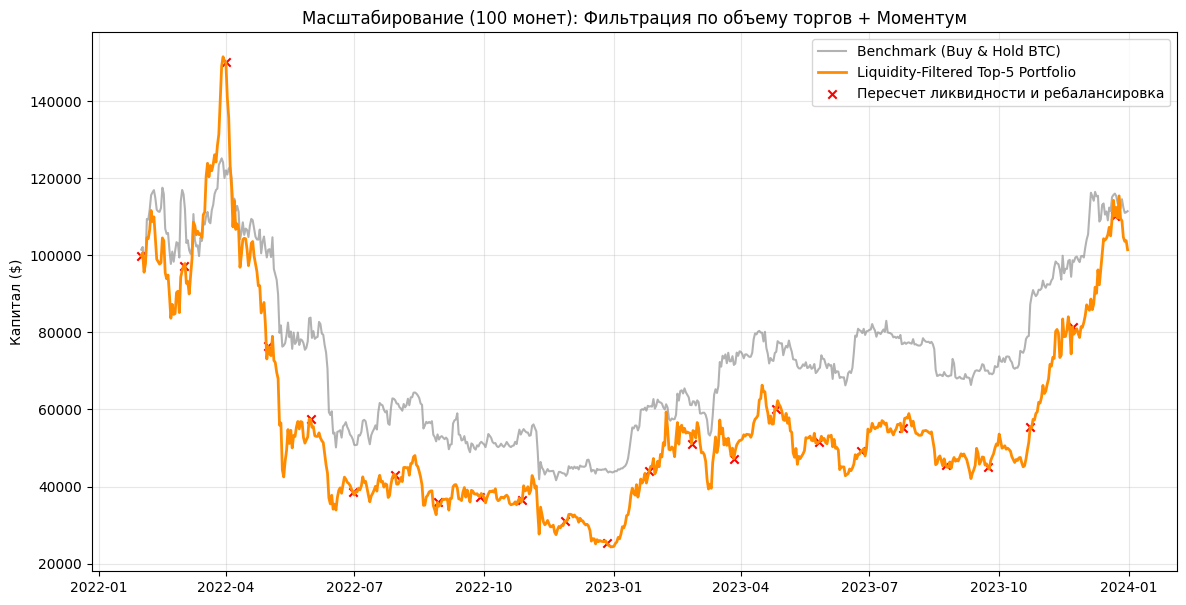

In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Формируем "Вселенную" из 100 тикеров
universe_tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'DOGE-USD',
    'DOT-USD', 'AVAX-USD', 'LINK-USD', 'LTC-USD', 'BCH-USD', 'MATIC-USD', 'XLM-USD',
    'ATOM-USD', 'UNI-USD', 'XMR-USD', 'ETC-USD', 'ALGO-USD', 'VET-USD', 'FIL-USD',
    'TRX-USD', 'EOS-USD', 'AAVE-USD', 'MKR-USD', 'QNT-USD', 'LDO-USD', 'SNX-USD',
    'THETA-USD', 'FTM-USD', 'EGLD-USD', 'SAND-USD', 'MANA-USD', 'AXS-USD', 'CHZ-USD',
    'RNDR-USD', 'CRV-USD', 'CAKE-USD', 'MINA-USD', 'GALA-USD', 'KAVA-USD', 'NEO-USD',
    'ZEC-USD', 'IOTA-USD', 'RUNE-USD', 'INJ-USD', 'XTZ-USD', '1INCH-USD', 'DASH-USD',
    'BAT-USD', 'ENJ-USD', 'ZIL-USD', 'GNO-USD', 'LRC-USD', 'QTUM-USD', 'CVX-USD',
    'BAL-USD', 'YFI-USD', 'SUSHI-USD', 'ENS-USD', 'GLM-USD', 'ILV-USD', 'AUDIO-USD',
    'YGG-USD', 'COMP-USD', 'KSM-USD', 'HOT-USD', 'CELO-USD', 'AR-USD', 'TFUEL-USD',
    'NEXO-USD', 'IOTX-USD', 'RVN-USD', 'ICX-USD', 'WAVES-USD', 'ONT-USD', 'WAXP-USD',
    'JST-USD', 'DGB-USD', 'SXP-USD', 'LSK-USD', 'CKB-USD', 'COTI-USD', 'SYS-USD',
    'DENT-USD', 'OCEAN-USD', 'CVC-USD', 'STORJ-USD', 'FET-USD', 'RLC-USD', 'BAND-USD',
    'STPT-USD', 'MTL-USD', 'TOMO-USD', 'NKN-USD', 'OXT-USD', 'NMR-USD', 'LPT-USD', 'MBL-USD'
]

print("Загрузка данных (Цена и Объем) для 100 пар...")
data = yf.download(universe_tickers, start="2022-01-01", end="2024-01-01")

# Вытаскиваем отдельно цены закрытия и объемы торгов
df_close = data['Close'].dropna(axis=1)
df_volume = data['Volume'].dropna(axis=1)

# Убедимся, что у нас одинаковый набор монет и там, и там
common_cols = df_close.columns.intersection(df_volume.columns)
df_close = df_close[common_cols]
df_volume = df_volume[common_cols]

print(f"Успешно загружены данные для {df_close.shape[1]} монет.")

daily_returns = df_close.pct_change().fillna(0)

# 2. Параметры фонда
initial_capital = 100000.0
fee_rate = 0.001          # Комиссия 0.1%
top_n = 5                 # Держим только Топ-5 монет
lookback_window = 30      # Анализ за 30 дней
rebalance_freq = 30       # Ребалансировка раз в 30 дней

# 3. Подготовка к симуляции
capital_history = []
current_capital = initial_capital
current_positions = pd.Series(0.0, index=df_close.columns)
rebalance_dates = []

btc_capital = initial_capital
btc_history = []

print("Запуск симуляции Liquidity-Filtered Momentum...")

# 4. Основной цикл
for i in range(lookback_window, len(df_close)):
    current_date = df_close.index[i]
    today_returns = daily_returns.iloc[i]

    current_positions = current_positions * (1 + today_returns)
    current_capital = current_positions.sum() if current_positions.sum() > 0 else current_capital

    btc_ret = today_returns['BTC-USD'] if 'BTC-USD' in today_returns else 0
    btc_capital = btc_capital * (1 + btc_ret)
    btc_history.append(btc_capital)

    # Шаг Б: Ребалансировка
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        past_month_close = df_close.iloc[i - lookback_window : i]
        past_month_volume = df_volume.iloc[i - lookback_window : i]

        # --- НОВЫЙ БЛОК: ИИ-Агент Фильтрации Ликвидности ---
        # Считаем средний дневной объем для каждой монеты за месяц
        adv = past_month_volume.mean()

        # Находим медиану объема (порог отсечения нижних 50%)
        volume_threshold = adv.quantile(0.50)

        # Оставляем только те монеты, объем которых выше порога (Ликвидный пул)
        liquid_coins = adv[adv >= volume_threshold].index

        # --- БЛОК МОМЕНТУМА ---
        # Считаем рост ТОЛЬКО для монет, прошедших проверку ликвидности
        momentum = (past_month_close[liquid_coins].iloc[-1] / past_month_close[liquid_coins].iloc[0]) - 1

        # Выбираем Топ-5 из чистого списка
        top_coins = momentum.nlargest(top_n).index
        target_weight = 1.0 / top_n

        target_positions = pd.Series(0.0, index=df_close.columns)
        for coin in top_coins:
            target_positions[coin] = current_capital * target_weight

        traded_value = np.abs(current_positions - target_positions).sum()
        fees = traded_value * fee_rate
        current_capital -= fees

        current_positions = target_positions * (current_capital / target_positions.sum()) if target_positions.sum() > 0 else target_positions

    capital_history.append(current_capital)

# 5. Расчет метрик
dates_plot = df_close.index[lookback_window:]
portfolio_series = pd.Series(capital_history, index=dates_plot)
btc_series = pd.Series(btc_history, index=dates_plot)

def calc_metrics(series):
    rets = series.pct_change().fillna(0)
    roi = (series.iloc[-1] / initial_capital - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    dd = ((series - series.cummax()) / series.cummax()).min() * 100
    return roi, sharpe, dd

strat_roi, strat_sharpe, strat_dd = calc_metrics(portfolio_series)
btc_roi, btc_sharpe, btc_dd = calc_metrics(btc_series)

print("-" * 50)
print("Уровень 5: Liquidity-Filtered Momentum (Топ-5 из ликвидных)")
print(f"ROI Стратегии: {strat_roi:.2f}% | ROI Биткоина (B&H): {btc_roi:.2f}%")
print(f"Sharpe Ratio: {strat_sharpe:.2f} | Sharpe Биткоина: {btc_sharpe:.2f}")
print(f"Max Drawdown: {strat_dd:.2f}% | Max Drawdown Биткоина: {btc_dd:.2f}%")
print("-" * 50)

# 6. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(btc_series, label=f'Benchmark (Buy & Hold BTC)', color='gray', alpha=0.6)
plt.plot(portfolio_series, label=f'Liquidity-Filtered Top-5 Portfolio', color='darkorange', linewidth=2)

plt.scatter(rebalance_dates, portfolio_series.loc[rebalance_dates], color='red', marker='x', label='Пересчет ликвидности и ребалансировка')

plt.title('Масштабирование (100 монет): Фильтрация по объему торгов + Моментум')
plt.ylabel('Капитал ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[                       0%                       ]

Загрузка данных для 100 пар...


[*********************100%***********************]  99 of 99 completed


Успешно загружены данные для 95 монет.
Запуск симуляции Absolute Momentum (С защитой капитала)...
--------------------------------------------------
Уровень 5: Absolute Momentum (Топ-5 + Защитный Кэш)
ROI Стратегии: 22.16% | ROI Биткоина (B&H): 11.47%
Sharpe Ratio: 0.51 | Sharpe Биткоина: 0.30
Max Drawdown: -81.00% | Max Drawdown Биткоина: -66.74%
--------------------------------------------------


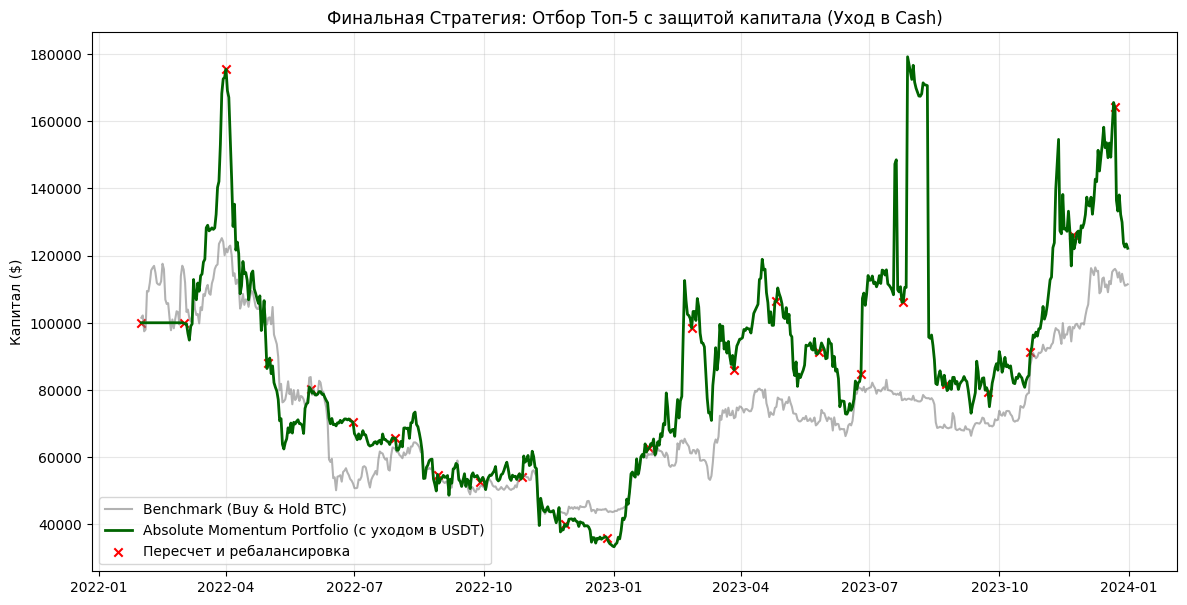

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Формируем "Вселенную" из 100 тикеров
universe_tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'DOGE-USD',
    'DOT-USD', 'AVAX-USD', 'LINK-USD', 'LTC-USD', 'BCH-USD', 'MATIC-USD', 'XLM-USD',
    'ATOM-USD', 'UNI-USD', 'XMR-USD', 'ETC-USD', 'ALGO-USD', 'VET-USD', 'FIL-USD',
    'TRX-USD', 'EOS-USD', 'AAVE-USD', 'MKR-USD', 'QNT-USD', 'LDO-USD', 'SNX-USD',
    'THETA-USD', 'FTM-USD', 'EGLD-USD', 'SAND-USD', 'MANA-USD', 'AXS-USD', 'CHZ-USD',
    'RNDR-USD', 'CRV-USD', 'CAKE-USD', 'MINA-USD', 'GALA-USD', 'KAVA-USD', 'NEO-USD',
    'ZEC-USD', 'IOTA-USD', 'RUNE-USD', 'INJ-USD', 'XTZ-USD', '1INCH-USD', 'DASH-USD',
    'BAT-USD', 'ENJ-USD', 'ZIL-USD', 'GNO-USD', 'LRC-USD', 'QTUM-USD', 'CVX-USD',
    'BAL-USD', 'YFI-USD', 'SUSHI-USD', 'ENS-USD', 'GLM-USD', 'ILV-USD', 'AUDIO-USD',
    'YGG-USD', 'COMP-USD', 'KSM-USD', 'HOT-USD', 'CELO-USD', 'AR-USD', 'TFUEL-USD',
    'NEXO-USD', 'IOTX-USD', 'RVN-USD', 'ICX-USD', 'WAVES-USD', 'ONT-USD', 'WAXP-USD',
    'JST-USD', 'DGB-USD', 'SXP-USD', 'LSK-USD', 'CKB-USD', 'COTI-USD', 'SYS-USD',
    'DENT-USD', 'OCEAN-USD', 'CVC-USD', 'STORJ-USD', 'FET-USD', 'RLC-USD', 'BAND-USD',
    'STPT-USD', 'MTL-USD', 'TOMO-USD', 'NKN-USD', 'OXT-USD', 'NMR-USD', 'LPT-USD', 'MBL-USD'
]

print("Загрузка данных для 100 пар...")
df_close = yf.download(universe_tickers, start="2022-01-01", end="2024-01-01")['Close'].dropna(axis=1)
daily_returns = df_close.pct_change().fillna(0)

print(f"Успешно загружены данные для {df_close.shape[1]} монет.")

# 2. Параметры фонда
initial_capital = 100000.0
fee_rate = 0.001          # Комиссия 0.1%
top_n = 5                 # Держим только Топ-5 монет
lookback_window = 30      # Анализ за 30 дней
rebalance_freq = 30       # Ребалансировка раз в 30 дней

# 3. Подготовка к симуляции (добавили учет КЭША)
capital_history = []
current_capital = initial_capital
current_cash = initial_capital  # На старте все деньги в USDT
current_positions = pd.Series(0.0, index=df_close.columns)
rebalance_dates = []

btc_capital = initial_capital
btc_history = []

print("Запуск симуляции Absolute Momentum (С защитой капитала)...")

# 4. Основной цикл
for i in range(lookback_window, len(df_close)):
    current_date = df_close.index[i]
    today_returns = daily_returns.iloc[i]

    # Шаг А: Обновление баланса (Инвестиции + Кэш)
    current_positions = current_positions * (1 + today_returns)
    current_capital = current_positions.sum() + current_cash

    btc_ret = today_returns['BTC-USD'] if 'BTC-USD' in today_returns else 0
    btc_capital = btc_capital * (1 + btc_ret)
    btc_history.append(btc_capital)

    # Шаг Б: Ребалансировка
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        past_month_close = df_close.iloc[i - lookback_window : i]
        momentum = (past_month_close.iloc[-1] / past_month_close.iloc[0]) - 1

        # Находим Топ-5
        top_coins = momentum.nlargest(top_n).index
        target_weight = 1.0 / top_n

        target_positions = pd.Series(0.0, index=df_close.columns)

        # --- НОВЫЙ БЛОК: Fail-Safe (Абсолютный Моментум) ---
        for coin in top_coins:
            if momentum[coin] > 0:  # ПОКУПАЕМ ТОЛЬКО ЕСЛИ РОСТ > 0%
                target_positions[coin] = current_capital * target_weight
            # Если рост < 0, деньги остаются в current_cash (USDT)

        # Считаем оборот и комиссии
        traded_value = np.abs(current_positions - target_positions).sum()
        fees = traded_value * fee_rate

        # Обновляем капитал: вычитаем комиссию
        current_capital -= fees

        # Фиксируем новые позиции и остаток переводим в кэш
        current_positions = target_positions.copy()
        current_cash = current_capital - current_positions.sum()

    capital_history.append(current_capital)

# 5. Расчет метрик
dates_plot = df_close.index[lookback_window:]
portfolio_series = pd.Series(capital_history, index=dates_plot)
btc_series = pd.Series(btc_history, index=dates_plot)

def calc_metrics(series):
    rets = series.pct_change().fillna(0)
    roi = (series.iloc[-1] / initial_capital - 1) * 100
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() != 0 else 0
    dd = ((series - series.cummax()) / series.cummax()).min() * 100
    return roi, sharpe, dd

strat_roi, strat_sharpe, strat_dd = calc_metrics(portfolio_series)
btc_roi, btc_sharpe, btc_dd = calc_metrics(btc_series)

print("-" * 50)
print("Уровень 5: Absolute Momentum (Топ-5 + Защитный Кэш)")
print(f"ROI Стратегии: {strat_roi:.2f}% | ROI Биткоина (B&H): {btc_roi:.2f}%")
print(f"Sharpe Ratio: {strat_sharpe:.2f} | Sharpe Биткоина: {btc_sharpe:.2f}")
print(f"Max Drawdown: {strat_dd:.2f}% | Max Drawdown Биткоина: {btc_dd:.2f}%")
print("-" * 50)

# 6. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(btc_series, label=f'Benchmark (Buy & Hold BTC)', color='gray', alpha=0.6)
plt.plot(portfolio_series, label=f'Absolute Momentum Portfolio (с уходом в USDT)', color='darkgreen', linewidth=2)

plt.scatter(rebalance_dates, portfolio_series.loc[rebalance_dates], color='red', marker='x', label='Пересчет и ребалансировка')

plt.title('Финальная Стратегия: Отбор Топ-5 с защитой капитала (Уход в Cash)')
plt.ylabel('Капитал ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In this final version, the trading universe has been scaled up to include the 100 most liquid cryptocurrency pairs, and a comparative backtest of the developed **Absolute Momentum** algorithm has been conducted against two independent benchmarks.

To execute the backtest under conditions closely approximating real-world market environments (institutional grade), the following enhancements were integrated into the mathematical model:

1. **Total Transaction Costs:** The execution cost parameter (set at 0.2% per trade) combines the exchange's base order execution fee (0.1%) with a mathematical model of **price slippage** and market spread (0.1%). This approach accurately accounts for hidden capital friction during large-scale portfolio rebalancing.
2. **Risk-Free Rate ($R_f$):** The risk-free return on capital ($R_f$) has been factored into the investment efficiency metrics (Sharpe and Sortino Ratios) at a rate of **4% per annum** (the equivalent yield of US Short-Term Treasury Bills). Consequently, these metrics isolate and evaluate strictly the algorithm's excess return per unit of risk taken relative to a risk-free cash allocation.

**Comparative Analysis Methodology (Benchmarks):**
The performance and efficacy of dynamic portfolio management are assessed by comparing the simulation results against two passive (Buy & Hold) strategies:

* **Benchmark 1 (Buy & Hold BTC):** Passive holding of Bitcoin as the primary proxy (index) for the broader cryptocurrency market.
* **Benchmark 2 (Static Top-5 Portfolio):** A passive portfolio established on day 30 of the backtest (immediately following the completion of the first rolling lookback window). Capital within this benchmark was allocated equally ($1/N$, at 20% each) among the initial momentum leaders and held without any subsequent rebalancing, weight adjustments, or capital flight into protective cash (USDT) until the end of the historical horizon.



[                       0%                       ]

Загрузка данных для 100 пар...


[*********************100%***********************]  99 of 99 completed


Успешно загружены данные для 95 монет.
-------------------------------------------------------------------------------------
Метрика                | AI Momentum (Динамика) | Изначальный Топ-5 (Статика) | B&H BTC     
-------------------------------------------------------------------------------------
Total ROI              | 17.70%                 | -43.57%                   | 9.83%       
Annualized Return      | 8.87%                  | -25.79%                   | 5.01%       
Max Drawdown           | -81.35%                | -79.00%                   | -66.74%     
Sharpe Ratio           | 0.05                   | -0.37                     | 0.02        
Sortino Ratio          | 0.06                   | -0.51                     | 0.02        
Calmar Ratio           | 0.11                   | -0.33                     | 0.08        
-------------------------------------------------------------------------------------


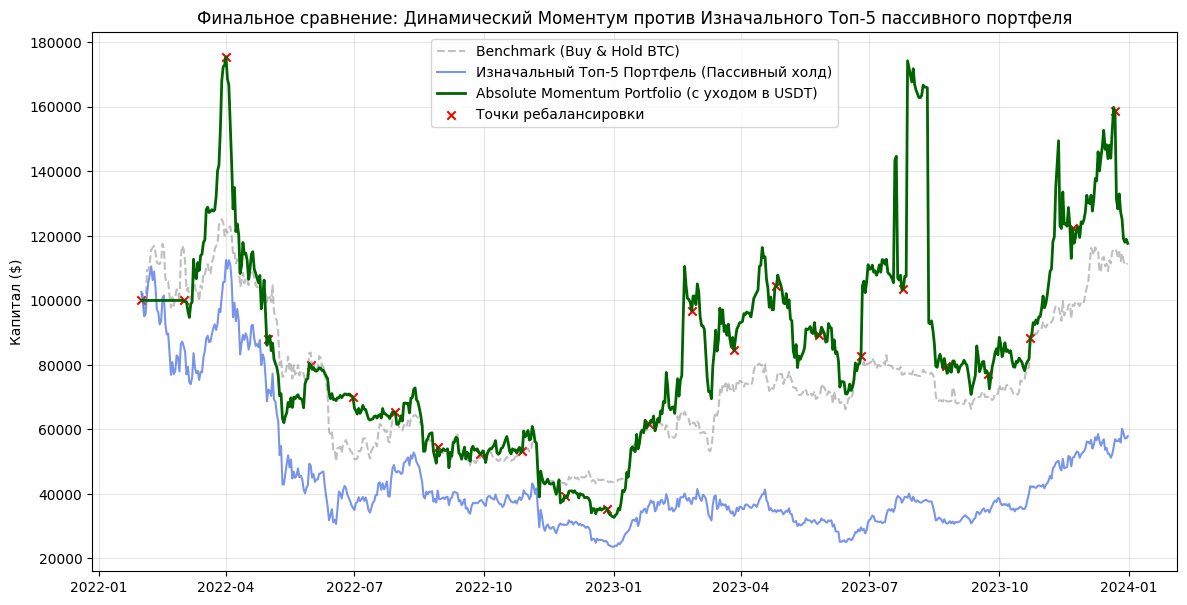

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. Формируем "Вселенную" из 100 тикеров
universe_tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD', 'DOGE-USD',
    'DOT-USD', 'AVAX-USD', 'LINK-USD', 'LTC-USD', 'BCH-USD', 'MATIC-USD', 'XLM-USD',
    'ATOM-USD', 'UNI-USD', 'XMR-USD', 'ETC-USD', 'ALGO-USD', 'VET-USD', 'FIL-USD',
    'TRX-USD', 'EOS-USD', 'AAVE-USD', 'MKR-USD', 'QNT-USD', 'LDO-USD', 'SNX-USD',
    'THETA-USD', 'FTM-USD', 'EGLD-USD', 'SAND-USD', 'MANA-USD', 'AXS-USD', 'CHZ-USD',
    'RNDR-USD', 'CRV-USD', 'CAKE-USD', 'MINA-USD', 'GALA-USD', 'KAVA-USD', 'NEO-USD',
    'ZEC-USD', 'IOTA-USD', 'RUNE-USD', 'INJ-USD', 'XTZ-USD', '1INCH-USD', 'DASH-USD',
    'BAT-USD', 'ENJ-USD', 'ZIL-USD', 'GNO-USD', 'LRC-USD', 'QTUM-USD', 'CVX-USD',
    'BAL-USD', 'YFI-USD', 'SUSHI-USD', 'ENS-USD', 'GLM-USD', 'ILV-USD', 'AUDIO-USD',
    'YGG-USD', 'COMP-USD', 'KSM-USD', 'HOT-USD', 'CELO-USD', 'AR-USD', 'TFUEL-USD',
    'NEXO-USD', 'IOTX-USD', 'RVN-USD', 'ICX-USD', 'WAVES-USD', 'ONT-USD', 'WAXP-USD',
    'JST-USD', 'DGB-USD', 'SXP-USD', 'LSK-USD', 'CKB-USD', 'COTI-USD', 'SYS-USD',
    'DENT-USD', 'OCEAN-USD', 'CVC-USD', 'STORJ-USD', 'FET-USD', 'RLC-USD', 'BAND-USD',
    'STPT-USD', 'MTL-USD', 'TOMO-USD', 'NKN-USD', 'OXT-USD', 'NMR-USD', 'LPT-USD', 'MBL-USD'
]

print("Загрузка данных для 100 пар...")
df_close = yf.download(universe_tickers, start="2022-01-01", end="2024-01-01")['Close'].dropna(axis=1)
daily_returns = df_close.pct_change().fillna(0)
print(f"Успешно загружены данные для {df_close.shape[1]} монет.")

# 2. Параметры фонда
initial_capital = 100000.0
transaction_cost_rate = 0.002 # Комиссия + проскальзывание = 0.2%
risk_free_rate = 0.04         # Безрисковая ставка 4%
top_n = 5
lookback_window = 30
rebalance_freq = 30

# 3. Подготовка к симуляции
capital_history = []
current_capital = initial_capital
current_cash = initial_capital
current_positions = pd.Series(0.0, index=df_close.columns)
rebalance_dates = []

# Бенчмарк 1: Только Биткоин
btc_capital = initial_capital
btc_history = []

# НОВОЕ: Переменные для пассивного удержания САМОГО ПЕРВОГО Топ-5 портфеля
static_top5_positions = pd.Series(0.0, index=df_close.columns)
static_top5_history = []
is_static_top5_initialized = False


# 4. Основной цикл
for i in range(lookback_window, len(df_close)):
    current_date = df_close.index[i]
    today_returns = daily_returns.iloc[i]

    # А. Наша динамическая стратегия (Absolute Momentum + Cash)
    current_positions = current_positions * (1 + today_returns)
    current_capital = current_positions.sum() + current_cash
    capital_history.append(current_capital)

    # Б. Бенчмарк 1: Рост Биткоина
    btc_ret = today_returns['BTC-USD'] if 'BTC-USD' in today_returns else 0
    btc_capital = btc_capital * (1 + btc_ret)
    btc_history.append(btc_capital)

    # В. Инициализация и расчет Изначального Топ-5 Портфеля (Buy & Hold)
    if not is_static_top5_initialized:
        # Считаем моментум за самый первый месяц наблюдений
        first_month_data = df_close.iloc[0 : lookback_window]
        first_momentum = (first_month_data.iloc[-1] / first_month_data.iloc[0]) - 1
        first_top_coins = first_momentum.nlargest(top_n).index

        # Инвестируем стартовый капитал по 20% в эти монеты за вычетом первой комиссии
        first_target_values = initial_capital * (1.0 / top_n)
        for coin in first_top_coins:
            static_top5_positions[coin] = first_target_values

        first_fees = initial_capital * transaction_cost_rate
        # Корректируем позиции с учетом уплаченной комиссии на старте
        static_top5_positions = static_top5_positions * ((initial_capital - first_fees) / initial_capital)
        is_static_top5_initialized = True

    # Рассчитываем пассивное изменение стоимости этого изначального портфеля
    static_top5_positions = static_top5_positions * (1 + today_returns)
    static_top5_history.append(static_top5_positions.sum())

    # Г. Логика ежемесячной динамической ребалансировки нашей основной стратегии
    if (i - lookback_window) % rebalance_freq == 0:
        rebalance_dates.append(current_date)

        past_month_close = df_close.iloc[i - lookback_window : i]
        momentum = (past_month_close.iloc[-1] / past_month_close.iloc[0]) - 1

        top_coins = momentum.nlargest(top_n).index
        target_weight = 1.0 / top_n

        target_positions = pd.Series(0.0, index=df_close.columns)

        for coin in top_coins:
            if momentum[coin] > 0:
                target_positions[coin] = current_capital * target_weight

        traded_value = np.abs(current_positions - target_positions).sum()
        costs = traded_value * transaction_cost_rate

        current_capital -= costs
        current_positions = target_positions.copy()
        current_cash = current_capital - current_positions.sum()

# 5. Вычисление расширенных метрик
dates_plot = df_close.index[lookback_window:]
portfolio_series = pd.Series(capital_history, index=dates_plot)
btc_series = pd.Series(btc_history, index=dates_plot)
static_top5_series = pd.Series(static_top5_history, index=dates_plot)

def calc_quant_metrics(series, rf_rate=0.04):
    rets = series.pct_change().fillna(0)
    total_roi = (series.iloc[-1] / series.iloc[0]) - 1
    years = len(series) / 365
    ann_return = (1 + total_roi) ** (1 / years) - 1 if years > 0 else 0
    ann_vol = rets.std() * np.sqrt(365)

    sharpe = (ann_return - rf_rate) / ann_vol if ann_vol != 0 else 0
    negative_rets = rets[rets < 0]
    downside_vol = negative_rets.std() * np.sqrt(365)
    sortino = (ann_return - rf_rate) / downside_vol if downside_vol != 0 else 0

    running_max = series.cummax()
    drawdown = (series - running_max) / running_max
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0

    return {
        "Total ROI": total_roi * 100,
        "Annualized Return": ann_return * 100,
        "Max Drawdown": max_dd * 100,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Calmar Ratio": calmar
    }

metrics_strat = calc_quant_metrics(portfolio_series, risk_free_rate)
metrics_btc = calc_quant_metrics(btc_series, risk_free_rate)
metrics_static5 = calc_quant_metrics(static_top5_series, risk_free_rate)

# Вывод сравнительной таблицы
print("-" * 85)
print(f"{'Метрика':<22} | {'AI Momentum (Динамика)':<22} | {'Изначальный Топ-5 (Статика)':<25} | {'B&H BTC':<12}")
print("-" * 85)
for key in metrics_strat.keys():
    if "Ratio" not in key:
        v_strat, v_stat5, v_btc = f"{metrics_strat[key]:.2f}%", f"{metrics_static5[key]:.2f}%", f"{metrics_btc[key]:.2f}%"
    else:
        v_strat, v_stat5, v_btc = f"{metrics_strat[key]:.2f}", f"{metrics_static5[key]:.2f}", f"{metrics_btc[key]:.2f}"
    print(f"{key:<22} | {v_strat:<22} | {v_stat5:<25} | {v_btc:<12}")
print("-" * 85)

# 6. Визуализация
plt.figure(figsize=(14, 7))
plt.plot(btc_series, label='Benchmark (Buy & Hold BTC)', color='gray', alpha=0.5, linestyle='--')
plt.plot(static_top5_series, label='Изначальный Топ-5 Портфель (Пассивный холд)', color='royalblue', alpha=0.7)
plt.plot(portfolio_series, label='Absolute Momentum Portfolio (с уходом в USDT)', color='darkgreen', linewidth=2)

plt.scatter(rebalance_dates, portfolio_series.loc[rebalance_dates], color='red', marker='x', label='Точки ребалансировки')

plt.title('Финальное сравнение: Динамический Моментум против Изначального Топ-5 пассивного портфеля')
plt.ylabel('Капитал ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()